In [20]:
# Importet
import numpy as np
import pandas as pd

# Utforskning av datasets #


In [21]:

# Hämta datan från npz filen - allow 
sequence = np.load('data/segment_sequences.npz')

# Se vad som finns i filen
print(sequence.files)


['X_seq', 'y_seq', 'groups', 'segment_id']


In [22]:
# Läs in csv-filen features för att utforska. 
df_features = pd.read_csv('data/segment_features.csv', sep=None, engine='python')

# Visa de första raderna så man får en överblick
df_features.head()

,segment_id,user_id,file_name,mode,n_points,duration_s,distance_m,avg_speed_mps,max_speed_mps,std_speed_mps,...,p90_speed_mps,avg_acc_mps2,std_acc_mps2,max_acc_mps2,min_acc_mps2,avg_turn_deg,std_turn_deg,stop_ratio,high_speed_ratio,mid_speed_ratio
0,0,10,20080331160008.plt,car,10,533.0,4997.940935,8.432578,13.554139,4.878132,...,12.967964,0.015542,0.120639,0.209189,-0.223434,9.418788,23.030978,0.200000,0.500000,0.100000
1,1,10,20080331160008.plt,car,12,651.0,6031.302622,8.480828,19.759260,6.057875,...,15.047145,0.004020,0.118478,0.256099,-0.202980,35.872241,45.273584,0.083333,0.416667,0.500000
2,2,10,20080402060926.plt,walk,563,1139.0,755.418664,1.083157,3.848027,0.478953,...,1.492055,0.010578,0.458360,2.223425,-2.384665,15.181143,15.664126,0.072824,0.000000,0.047957
3,3,10,20080402060926.plt,car,175,203.0,1073.949583,5.936181,12.483375,3.656538,...,10.732234,0.073373,0.735080,2.943170,-2.004067,7.713667,9.935911,0.040000,0.211429,0.468571
4,4,10,20080402060926.plt,bus,266,1584.0,7326.510691,6.984778,16.513127,3.722160,...,11.717630,0.078682,1.053435,6.402394,-5.108211,6.752381,17.676938,0.045113,0.251880,0.481203


In [23]:
# Läs in csv-filen metadata för att utforska. 
df_metadata = pd.read_csv('data/segment_metadata.csv', sep=None, engine='python')

# Visa de första raderna så man får en överblick
df_metadata.head()

,segment_id,user_id,file_name,mode
0,0,10,20080331160008.plt,car
1,1,10,20080331160008.plt,car
2,2,10,20080402060926.plt,walk
3,3,10,20080402060926.plt,car
4,4,10,20080402060926.plt,bus


### Kommentar ###

**.npz filen:**  Vet inte om vi behöver den? Vet inte riktigt hur man ska göra med den datan eller hur man använder den?

**feature filen:** Här har vi all data vi behöver. features, targets(mode) och ev all userId:s och segmentsID:s.

**metadata filen:** Här har vi samma data som i featuredatan förutom alla features. Vi behöver kanske inte denna fil heller?



# Task 1: Feature engineering and Machine Learning Model #


In [ ]:
# Importerar dom bibliotek vi behöver

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print ('Bibliotek är importerade')

Bibliotek är importerade


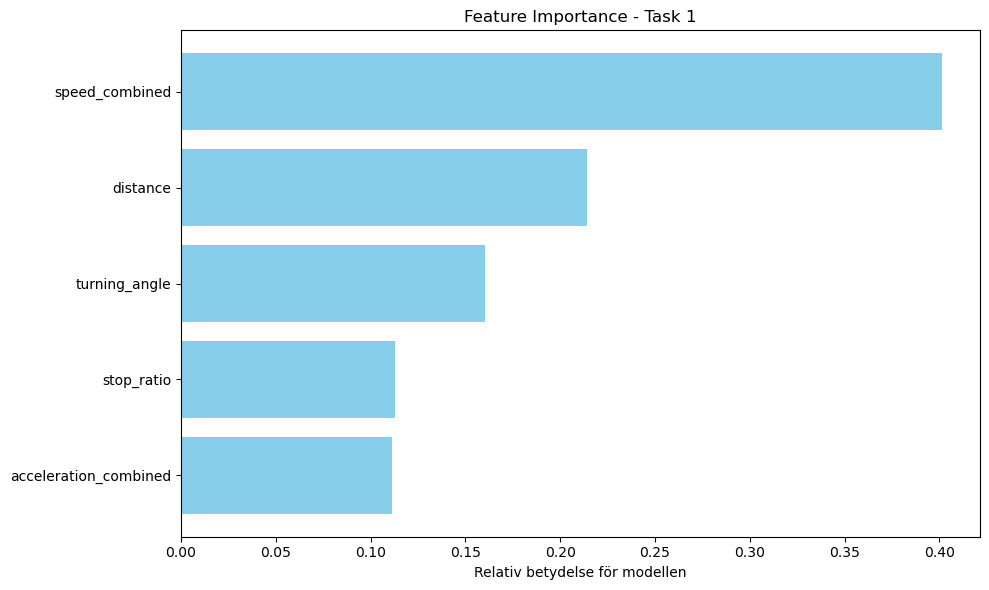

Modellens träffsäkerhet: 0.8252427184466019


In [ ]:

# Skapa (kombinera) de features som efterfrågas
# Vi skapar tydliga huvudkategorier baserat på den preprocessed datan
df_final = pd.DataFrame()
df_final['mode'] = df_features['mode'] # Målvariabel

# Speed (Kombinerar olika hastighetsmått)
df_final['speed_combined'] = df_features[['avg_speed_mps', 'p50_speed_mps', 'p90_speed_mps']].mean(axis=1)

# Acceleration (Kombinerar snitt och max acceleration)
df_final['acceleration_combined'] = df_features[['avg_acc_mps2', 'max_acc_mps2']].mean(axis=1)

# Distance
df_final['distance'] = df_features['distance_m']

# Turning angle
df_final['turning_angle'] = df_features['avg_turn_deg']

# Stop ratio
df_final['stop_ratio'] = df_features['stop_ratio']

# Förbered för ML-modell
X = df_final.drop('mode', axis=1)
y = df_final['mode']

# Dela upp i tränings(80%)- och testdata(20%) med random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Träna Random Forest för att få Feature Importance med random_state för reproducerbarhet
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generera Feature Importance Plot
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Task 1')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relativ betydelse för modellen')
plt.tight_layout()
plt.show()

print("Modellens träffsäkerhet:", model.score(X_test, y_test))